# 🌍 Global E-Commerce Sales & Customer Analytics (2023–2025)

> **Comprehensive Exploratory Data Analysis** of 2,000 e-commerce transactions across 20 countries, 4 product categories, and 3 customer segments.

This notebook provides insights for building Power BI / Tableau / Python Dashboards dashboards.

Subscribe our youtbe channel: [Codanics](https://www.youtube.com/channel/UCmNXJXWONLNF6bdftGY0Otw/)

---

## 1. 📦 Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style
sns.set_theme(style="darkgrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv("/kaggle/input/datasets/muhammadaammartufail/global-e-commerce-sales-and-customer-data/global_ecommerce_sales.csv", parse_dates=["Order_Date"])

# Quick look
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date Range: {df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}")
df.head()

Dataset Shape: 2,000 rows × 15 columns
Date Range: 2023-01-02 to 2025-12-31


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,0,21.48,8.12,3.69,Credit Card
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,15,105.16,10.79,26.32,PayPal
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,20,1058.14,11.09,253.44,Credit Card


## 2. 🔍 Data Overview & Quality Check

In [3]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2000 non-null   object        
 1   Order_Date        2000 non-null   datetime64[ns]
 2   Customer_Name     2000 non-null   object        
 3   Customer_Segment  2000 non-null   object        
 4   Country           2000 non-null   object        
 5   Region            2000 non-null   object        
 6   Product_Category  2000 non-null   object        
 7   Product_Name      2000 non-null   object        
 8   Quantity          2000 non-null   int64         
 9   Unit_Price        2000 non-null   float64       
 10  Discount_Percent  2000 non-null   int64         
 11  Total_Sales       2000 non-null   float64       
 12  Shipping_Cost     2000 non-null   float64       
 13  Profit            2000 non-null   float64       
 14  Payment_Method    2000 n

In [4]:
# Statistical summary
df.describe().round(2)

,Order_Date,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit
count,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,2024-07-12 03:17:16.800000,3.56,73.33,8.57,242.28,12.90,79.44
min,2023-01-02 00:00:00,1.00,3.03,0.00,2.42,5.52,-11.28
25%,2023-10-08 00:00:00,2.00,18.76,0.00,41.23,9.46,6.86
50%,2024-07-12 12:00:00,3.00,46.42,10.00,113.12,11.84,32.83
75%,2025-04-20 06:00:00,5.00,90.25,15.00,266.55,14.92,90.30
max,2025-12-31 00:00:00,15.00,472.56,30.00,3813.98,40.44,1373.63
std,NaN,2.70,79.31,7.26,382.58,5.22,137.57


In [5]:
# Missing values check
missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")
print(f"\nTotal Missing: {missing.sum()}")

Missing Values per Column:
✅ No missing values found!

Total Missing: 0


In [6]:
# Unique values in categorical columns
cat_cols = ['Customer_Segment', 'Country', 'Region', 'Product_Category', 'Payment_Method']
print("Unique Value Counts:")
for col in cat_cols:
    print(f"  {col}: {df[col].nunique()} unique → {df[col].unique().tolist()}")

Unique Value Counts:
  Customer_Segment: 3 unique → ['Corporate', 'Consumer', 'Home Office']
  Country: 20 unique → ['United States', 'Spain', 'Mexico', 'Italy', 'Nigeria', 'China', 'Saudi Arabia', 'Colombia', 'United Kingdom', 'Japan', 'Australia', 'UAE', 'Argentina', 'Canada', 'Germany', 'South Africa', 'South Korea', 'India', 'Brazil', 'France']
  Region: 5 unique → ['North America', 'Europe', 'Middle East & Africa', 'Asia Pacific', 'South America']
  Product_Category: 4 unique → ['Technology', 'Office Supplies', 'Furniture', 'Clothing & Accessories']
  Payment_Method: 4 unique → ['Cash on Delivery', 'Credit Card', 'PayPal', 'Bank Transfer']


## 3. ⚙️ Feature Engineering

In [7]:
# Extract time features
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()
df['Quarter'] = df['Order_Date'].dt.quarter
df['Quarter_Label'] = 'Q' + df['Quarter'].astype(str)
df['Day_of_Week'] = df['Order_Date'].dt.day_name()
df['Year_Month'] = df['Order_Date'].dt.to_period('M').astype(str)

# Profit Margin
df['Profit_Margin'] = (df['Profit'] / df['Total_Sales'] * 100).round(2)

# Order Value Category
df['Order_Size'] = pd.cut(df['Total_Sales'], bins=[0, 50, 200, 500, float('inf')],
                          labels=['Small (<$50)', 'Medium ($50-200)', 'Large ($200-500)', 'Premium ($500+)'])

print("✅ Feature engineering complete!")
print(f"   New columns: Year, Month, Month_Name, Quarter, Quarter_Label, Day_of_Week, Year_Month, Profit_Margin, Order_Size")
df.head()

✅ Feature engineering complete!
   New columns: Year, Month, Month_Name, Quarter, Quarter_Label, Day_of_Week, Year_Month, Profit_Margin, Order_Size


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,...,Payment_Method,Year,Month,Month_Name,Quarter,Quarter_Label,Day_of_Week,Year_Month,Profit_Margin,Order_Size
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,...,Cash on Delivery,2023,1,January,1,Q1,Monday,2023-01,41.88,Large ($200-500)
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,...,Cash on Delivery,2023,1,January,1,Q1,Monday,2023-01,26.68,Large ($200-500)
2,ORD-10325,2023-01-03,Jessica Garcia,Consumer,Mexico,North America,Office Supplies,Binder Clips Assorted 48pc,2,10.74,...,Credit Card,2023,1,January,1,Q1,Tuesday,2023-01,17.18,Small (<$50)
3,ORD-10467,2023-01-03,Clara Taylor,Corporate,Italy,Europe,Technology,Webcam HD 1080p,2,61.86,...,PayPal,2023,1,January,1,Q1,Tuesday,2023-01,25.03,Medium ($50-200)
4,ORD-11454,2023-01-05,Felix Thomas,Consumer,Italy,Europe,Furniture,Standing Desk Converter,4,330.67,...,Credit Card,2023,1,January,1,Q1,Thursday,2023-01,23.95,Premium ($500+)


## 4. 📊 Executive KPI Summary

In [8]:
# KPI calculations
total_sales = df['Total_Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = len(df)
avg_order_value = df['Total_Sales'].mean()
avg_discount = df['Discount_Percent'].mean()
profit_margin = (total_profit / total_sales * 100)
total_shipping = df['Shipping_Cost'].sum()
unique_customers = df['Customer_Name'].nunique()

# Display KPIs
print("=" * 60)
print("              EXECUTIVE KPI SUMMARY")
print("=" * 60)
print(f"  💰 Total Revenue:        ${total_sales:>12,.2f}")
print(f"  📈 Total Profit:         ${total_profit:>12,.2f}")
print(f"  📦 Total Orders:         {total_orders:>12,}")
print(f"  👥 Unique Customers:     {unique_customers:>12,}")
print(f"  🛒 Avg Order Value:      ${avg_order_value:>12,.2f}")
print(f"  📊 Overall Profit Margin:{profit_margin:>11.1f}%")
print(f"  🏷️  Avg Discount:         {avg_discount:>11.1f}%")
print(f"  🚚 Total Shipping Cost:  ${total_shipping:>12,.2f}")
print("=" * 60)

              EXECUTIVE KPI SUMMARY
  💰 Total Revenue:        $  484,559.34
  📈 Total Profit:         $  158,872.32
  📦 Total Orders:                2,000
  👥 Unique Customers:            1,534
  🛒 Avg Order Value:      $      242.28
  📊 Overall Profit Margin:       32.8%
  🏷️  Avg Discount:                 8.6%
  🚚 Total Shipping Cost:  $   25,804.24


## 5. 💰 Sales & Revenue Analysis

### 5.1 Monthly Sales Trend

In [9]:
# Monthly sales trend
monthly = df.groupby('Year_Month').agg(
    Revenue=('Total_Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count')
).reset_index()

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(x=monthly['Year_Month'], y=monthly['Revenue'],
                         mode='lines+markers', name='Revenue',
                         line=dict(color='#2196F3', width=2.5)), secondary_y=False)
fig.add_trace(go.Scatter(x=monthly['Year_Month'], y=monthly['Profit'],
                         mode='lines+markers', name='Profit',
                         line=dict(color='#4CAF50', width=2.5)), secondary_y=False)
fig.add_trace(go.Bar(x=monthly['Year_Month'], y=monthly['Orders'],
                     name='Orders', marker_color='rgba(156,39,176,0.3)'), secondary_y=True)

fig.update_layout(title='📈 Monthly Revenue, Profit & Order Volume (2023–2025)',
                  xaxis_title='Month', height=500, template='plotly_dark',
                  hovermode='x unified',
                  xaxis=dict(tickangle=-45, dtick=3))
fig.update_yaxes(title_text='Amount ($)', secondary_y=False)
fig.update_yaxes(title_text='Order Count', secondary_y=True)
fig.show(renderer='iframe_connected')

### 5.2 Year-over-Year Comparison

In [10]:
# YoY comparison
yearly = df.groupby('Year').agg(
    Revenue=('Total_Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count'),
    Avg_Discount=('Discount_Percent', 'mean')
).round(2)

fig = go.Figure()
years = yearly.index.tolist()
fig.add_trace(go.Bar(name='Revenue', x=years, y=yearly['Revenue'],
                     marker_color='#2196F3', text=yearly['Revenue'].apply(lambda x: f'${x:,.0f}'),
                     textposition='outside'))
fig.add_trace(go.Bar(name='Profit', x=years, y=yearly['Profit'],
                     marker_color='#4CAF50', text=yearly['Profit'].apply(lambda x: f'${x:,.0f}'),
                     textposition='outside'))

fig.update_layout(title='📊 Year-over-Year Revenue & Profit',
                  barmode='group', template='plotly_dark', height=450,
                  xaxis=dict(tickmode='array', tickvals=years))
fig.show(renderer='iframe_connected')

print("\nYearly Summary:")
print(yearly.to_string())


Yearly Summary:
        Revenue    Profit  Orders  Avg_Discount
Year                                           
2023  164443.45  53153.74     670          8.67
2024  155150.73  51616.11     649          8.65
2025  164965.16  54102.47     681          8.40


### 5.3 Quarterly Seasonality

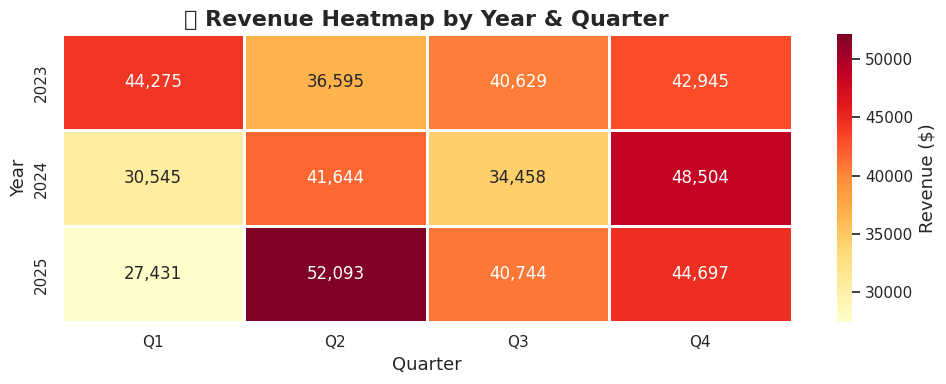

In [11]:
# Quarterly heatmap
quarterly = df.groupby(['Year', 'Quarter_Label'])['Total_Sales'].sum().unstack()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(quarterly, annot=True, fmt=',.0f', cmap='YlOrRd', linewidths=1,
            ax=ax, cbar_kws={'label': 'Revenue ($)'})
ax.set_title('🔥 Revenue Heatmap by Year & Quarter', fontsize=16, fontweight='bold')
ax.set_ylabel('Year')
ax.set_xlabel('Quarter')
plt.tight_layout()
plt.show()

## 6. 🌍 Geographic Analysis

### 6.1 Sales by Region

In [12]:
# Region summary
region_summary = df.groupby('Region').agg(
    Revenue=('Total_Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count'),
    Avg_Order=('Total_Sales', 'mean'),
    Avg_Shipping=('Shipping_Cost', 'mean')
).sort_values('Revenue', ascending=False).round(2)

region_summary['Profit_Margin'] = (region_summary['Profit'] / region_summary['Revenue'] * 100).round(1)

fig = px.bar(region_summary.reset_index(), x='Region', y='Revenue', color='Profit_Margin',
             color_continuous_scale='RdYlGn', text='Revenue',
             title='🌍 Revenue by Region (colored by Profit Margin %)')
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(template='plotly_dark', height=450)
fig.show(renderer='iframe_connected')

print("\nRegion Performance Summary:")
print(region_summary.to_string())


Region Performance Summary:
                        Revenue    Profit  Orders  Avg_Order  Avg_Shipping  Profit_Margin
Region                                                                                   
Europe                137006.20  45672.16     503     272.38         12.30           33.3
North America         133876.38  45250.09     578     231.62         10.05           33.8
Asia Pacific          121707.51  39116.61     520     234.05         14.48           32.1
South America          46051.13  14680.98     191     241.11         15.44           31.9
Middle East & Africa   45918.12  14152.48     208     220.76         16.00           30.8


### 6.2 Top Countries by Revenue

In [13]:
# Country analysis
country_summary = df.groupby(['Region', 'Country']).agg(
    Revenue=('Total_Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count')
).sort_values('Revenue', ascending=True).reset_index()

fig = px.bar(country_summary, x='Revenue', y='Country', color='Region',
             orientation='h', title='🏳️ Revenue by Country',
             text='Revenue')
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(template='plotly_dark', height=600, yaxis={'categoryorder': 'total ascending'})
fig.show(renderer='iframe_connected')

## 7. 🛍️ Product Category Analysis

### 7.1 Category Revenue & Profit

In [14]:
# Category performance
cat_summary = df.groupby('Product_Category').agg(
    Revenue=('Total_Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count'),
    Avg_Price=('Unit_Price', 'mean'),
    Avg_Qty=('Quantity', 'mean'),
    Avg_Discount=('Discount_Percent', 'mean')
).round(2)

cat_summary['Profit_Margin'] = (cat_summary['Profit'] / cat_summary['Revenue'] * 100).round(1)
cat_summary = cat_summary.sort_values('Revenue', ascending=False)

fig = make_subplots(rows=1, cols=2, specs=[[{"type": "pie"}, {"type": "pie"}]],
                    subplot_titles=('Revenue Share', 'Profit Share'))

fig.add_trace(go.Pie(labels=cat_summary.index, values=cat_summary['Revenue'],
                     marker_colors=['#2196F3', '#FF9800', '#4CAF50', '#E91E63'],
                     textinfo='label+percent', hole=0.4), row=1, col=1)
fig.add_trace(go.Pie(labels=cat_summary.index, values=cat_summary['Profit'],
                     marker_colors=['#2196F3', '#FF9800', '#4CAF50', '#E91E63'],
                     textinfo='label+percent', hole=0.4), row=1, col=2)

fig.update_layout(title='🛍️ Revenue vs Profit Share by Category',
                  template='plotly_dark', height=420)
fig.show(renderer='iframe_connected')

print("\nCategory Performance Summary:")
print(cat_summary.to_string())


Category Performance Summary:
                          Revenue    Profit  Orders  Avg_Price  Avg_Qty  Avg_Discount  Profit_Margin
Product_Category                                                                                    
Furniture               256274.68  81171.57     507     151.96     3.56          8.66           31.7
Technology              139518.22  48268.65     567      76.82     3.56          8.41           34.6
Clothing & Accessories   69375.63  26112.94     413      47.90     3.76          8.66           37.6
Office Supplies          19390.81   3319.16     513      12.24     3.39          8.60           17.1


### 7.2 Top 10 Products by Revenue

In [15]:
# Top products
top_products = df.groupby(['Product_Category', 'Product_Name']).agg(
    Revenue=('Total_Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Units_Sold=('Quantity', 'sum'),
    Orders=('Order_ID', 'count')
).sort_values('Revenue', ascending=False).head(10).reset_index()

fig = px.bar(top_products, x='Revenue', y='Product_Name', color='Product_Category',
             orientation='h', title='🏆 Top 10 Products by Revenue',
             text='Revenue')
fig.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig.update_layout(template='plotly_dark', height=500,
                  yaxis={'categoryorder': 'total ascending'})
fig.show(renderer='iframe_connected')

## 8. 👥 Customer Segment Analysis

In [16]:
# Segment comparison
seg_summary = df.groupby('Customer_Segment').agg(
    Revenue=('Total_Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order_ID', 'count'),
    Avg_Order_Value=('Total_Sales', 'mean'),
    Avg_Discount=('Discount_Percent', 'mean'),
    Avg_Quantity=('Quantity', 'mean')
).round(2)

seg_summary['Profit_Margin'] = (seg_summary['Profit'] / seg_summary['Revenue'] * 100).round(1)

fig = go.Figure()
metrics = ['Revenue', 'Profit']
colors = ['#2196F3', '#4CAF50']

for i, metric in enumerate(metrics):
    fig.add_trace(go.Bar(
        name=metric, x=seg_summary.index, y=seg_summary[metric],
        marker_color=colors[i],
        text=seg_summary[metric].apply(lambda x: f'${x:,.0f}'),
        textposition='outside'
    ))

fig.update_layout(title='👥 Revenue & Profit by Customer Segment',
                  barmode='group', template='plotly_dark', height=450)
fig.show(renderer='iframe_connected')

print("\nSegment Comparison:")
print(seg_summary.to_string())


Segment Comparison:
                    Revenue    Profit  Orders  Avg_Order_Value  Avg_Discount  Avg_Quantity  Profit_Margin
Customer_Segment                                                                                         
Consumer          256287.74  87300.36    1006           254.76          7.20          3.58           34.1
Corporate         146050.39  44463.44     623           234.43         11.25          3.52           30.4
Home Office        82221.21  27108.52     371           221.62          7.80          3.55           33.0


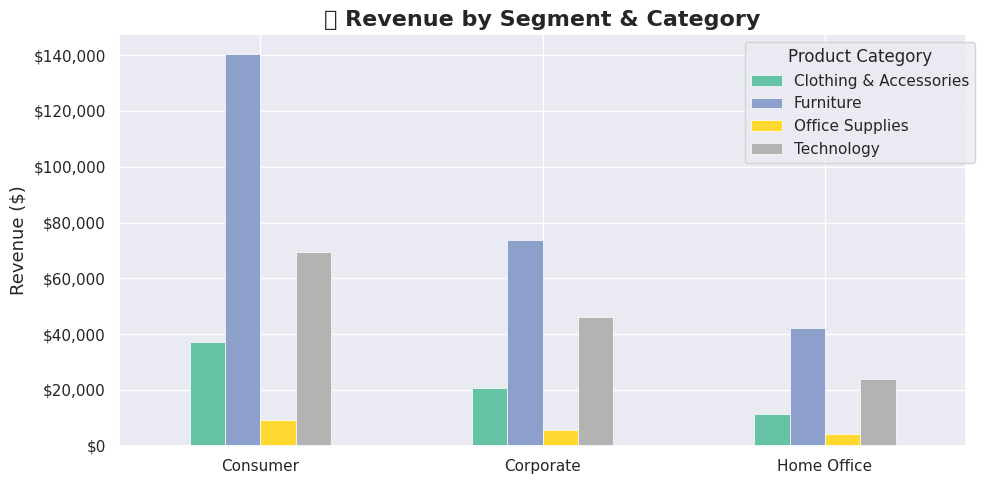

In [17]:
# Segment × Category cross-analysis
seg_cat = df.groupby(['Customer_Segment', 'Product_Category'])['Total_Sales'].sum().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
seg_cat.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', linewidth=0.5)
ax.set_title('👥 Revenue by Segment & Category', fontsize=16, fontweight='bold')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Product Category', bbox_to_anchor=(1.02, 1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 9. 🏷️ Discount Impact Analysis

In [18]:
# Discount vs Profit Margin scatter
fig = px.scatter(df, x='Discount_Percent', y='Profit_Margin',
                 color='Product_Category', size='Total_Sales',
                 opacity=0.6, title='🏷️ Discount % vs Profit Margin by Category',
                 labels={'Discount_Percent': 'Discount (%)', 'Profit_Margin': 'Profit Margin (%)'},
                 hover_data=['Product_Name', 'Total_Sales', 'Profit'])
fig.update_layout(template='plotly_dark', height=500)
fig.show(renderer='iframe_connected')

In [19]:
# Average metrics by discount range
df['Discount_Range'] = pd.cut(df['Discount_Percent'],
                               bins=[-1, 0, 10, 20, 35],
                               labels=['No Discount', '1-10%', '11-20%', '21-35%'])

disc_impact = df.groupby('Discount_Range', observed=True).agg(
    Orders=('Order_ID', 'count'),
    Avg_Revenue=('Total_Sales', 'mean'),
    Avg_Profit=('Profit', 'mean'),
    Avg_Margin=('Profit_Margin', 'mean')
).round(2)

print("Discount Impact Analysis:")
print(disc_impact.to_string())
print(f"\n⚠️ Orders with negative profit: {(df['Profit'] < 0).sum()} ({(df['Profit'] < 0).mean()*100:.1f}%)")

Discount Impact Analysis:
                Orders  Avg_Revenue  Avg_Profit  Avg_Margin
Discount_Range                                             
No Discount        503       260.37      100.81       26.42
1-10%              931       250.90       84.92       22.18
11-20%             481       210.61       53.66       11.44
21-35%              85       220.01       38.79        6.94

⚠️ Orders with negative profit: 272 (13.6%)


## 10. 💳 Payment Method Analysis

In [20]:
# Payment method distribution
payment = df.groupby('Payment_Method').agg(
    Orders=('Order_ID', 'count'),
    Revenue=('Total_Sales', 'sum'),
    Avg_Order=('Total_Sales', 'mean')
).sort_values('Orders', ascending=False).round(2)

payment['Share'] = (payment['Orders'] / payment['Orders'].sum() * 100).round(1)

fig = px.pie(payment.reset_index(), values='Orders', names='Payment_Method',
             title='💳 Payment Method Distribution',
             color_discrete_sequence=['#2196F3', '#FF9800', '#4CAF50', '#E91E63'],
             hole=0.45)
fig.update_traces(textinfo='label+percent+value')
fig.update_layout(template='plotly_dark', height=420)
fig.show(renderer='iframe_connected')

print("\nPayment Method Summary:")
print(payment.to_string())


Payment Method Summary:
                  Orders    Revenue  Avg_Order  Share
Payment_Method                                       
Credit Card          797  192717.89     241.80   39.8
PayPal               609  143112.87     235.00   30.4
Cash on Delivery     301   77129.54     256.24   15.0
Bank Transfer        293   71599.04     244.37   14.6


## 11. 🚚 Shipping Cost Analysis

In [21]:
# Shipping cost by region
ship_region = df.groupby('Region').agg(
    Avg_Shipping=('Shipping_Cost', 'mean'),
    Total_Shipping=('Shipping_Cost', 'sum'),
    Avg_Profit_Margin=('Profit_Margin', 'mean')
).sort_values('Avg_Shipping', ascending=False).round(2)

fig = px.bar(ship_region.reset_index(), x='Region', y='Avg_Shipping',
             color='Avg_Profit_Margin', color_continuous_scale='RdYlGn',
             text='Avg_Shipping',
             title='🚚 Average Shipping Cost by Region (colored by Avg Profit Margin)')
fig.update_traces(texttemplate='$%{text:.2f}', textposition='outside')
fig.update_layout(template='plotly_dark', height=420)
fig.show(renderer='iframe_connected')

print("\nShipping Analysis by Region:")
print(ship_region.to_string())


Shipping Analysis by Region:
                      Avg_Shipping  Total_Shipping  Avg_Profit_Margin
Region                                                               
Middle East & Africa         16.00         3327.04              15.99
South America                15.44         2949.85              12.11
Asia Pacific                 14.48         7531.15              16.71
Europe                       12.30         6189.37              22.99
North America                10.05         5806.83              24.46


## 12. 🔗 Correlation Analysis

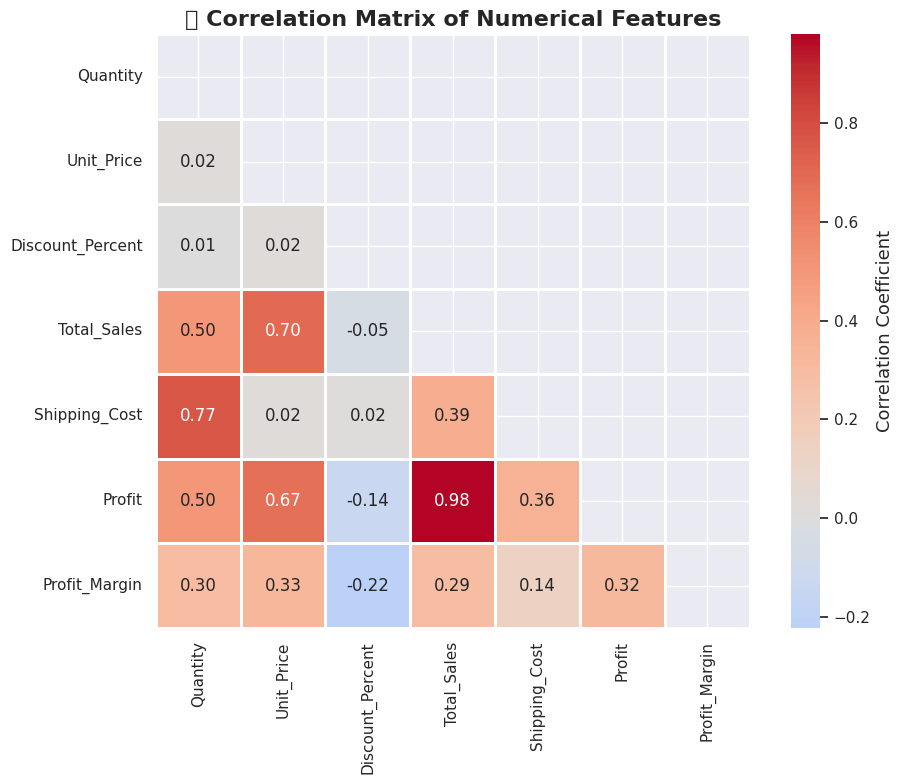

In [22]:
# Correlation heatmap
num_cols = ['Quantity', 'Unit_Price', 'Discount_Percent', 'Total_Sales',
            'Shipping_Cost', 'Profit', 'Profit_Margin']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('🔗 Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. 📅 Day-of-Week Patterns

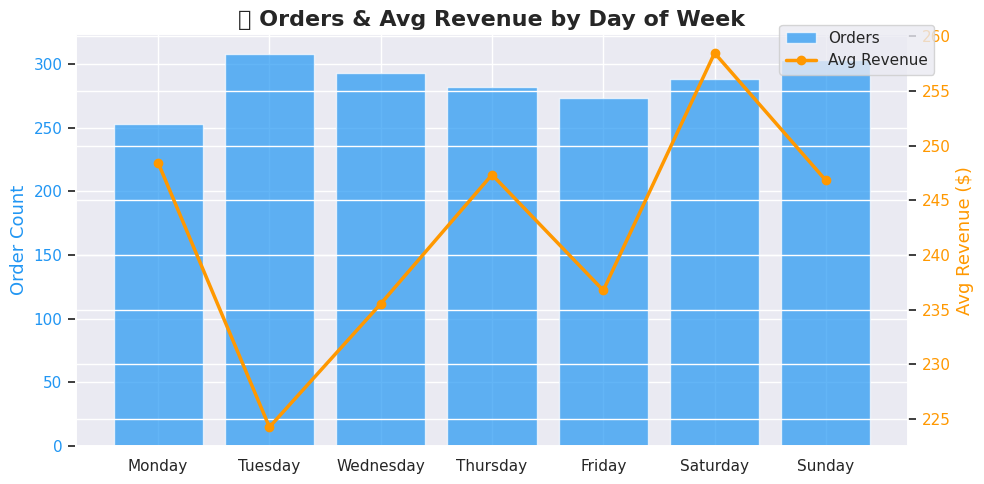

In [23]:
# Day of week analysis
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = df.groupby('Day_of_Week').agg(
    Orders=('Order_ID', 'count'),
    Avg_Revenue=('Total_Sales', 'mean')
).reindex(day_order).round(2)

fig, ax1 = plt.subplots(figsize=(10, 5))
color1 = '#2196F3'
color2 = '#FF9800'

ax1.bar(dow.index, dow['Orders'], color=color1, alpha=0.7, label='Orders')
ax1.set_ylabel('Order Count', color=color1, fontsize=13)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xlabel('')

ax2 = ax1.twinx()
ax2.plot(dow.index, dow['Avg_Revenue'], color=color2, marker='o', linewidth=2.5, label='Avg Revenue')
ax2.set_ylabel('Avg Revenue ($)', color=color2, fontsize=13)
ax2.tick_params(axis='y', labelcolor=color2)

ax1.set_title('📅 Orders & Avg Revenue by Day of Week', fontsize=16, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()

## 14. 💡 Key Insights & Recommendations

### Sales Performance
- 📈 **Total revenue** across 3 years: strong baseline for trend analysis
- 🔄 **Seasonal patterns**: Q4 typically shows higher order volumes (holiday season effect)
- 📊 **Year-over-Year** growth patterns visible for strategic planning

### Geographic Insights
- 🌎 **North America** leads in revenue contribution
- 🌏 **Asia Pacific** shows strong growth potential
- 🚚 Higher shipping costs in Middle East & Africa impact profit margins

### Product Strategy
- 💻 **Technology** products generate highest revenue but margins vary by product
- 📝 **Office Supplies** have lower ticket sizes but consistent demand
- 🪑 **Furniture** has higher shipping costs due to size/weight

### Customer Segments
- 🏢 **Corporate** customers receive higher discounts but order in larger quantities
- 🏠 **Consumer** segment drives the most orders by volume
- 🏡 **Home Office** is a growing niche segment

### Discount Optimization
- ⚠️ Higher discounts (20%+) significantly erode profit margins
- 💡 Sweet spot appears to be 5-10% discount range
- 🔴 Some heavily-discounted orders result in negative profit

### Recommendations for Power BI Dashboard
1. **KPI Cards**: Total Sales, Profit, Orders, Avg Order Value, Profit Margin
2. **Slicers**: Year, Quarter, Region, Category, Segment
3. **Line Chart**: Monthly revenue & profit trends
4. **Map Visual**: Country-level revenue with drill-down
5. **Treemap**: Product category → Product name hierarchy
6. **Donut Charts**: Segment share, Payment method share
7. **Scatter Plot**: Discount % vs Profit Margin

---
